In [512]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [513]:
df = pd.read_csv(r"C:\Users\kunwa\PycharmProjects\ML\PCA\train.csv")

In [514]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [515]:
df = df.drop(columns = ["PassengerId","Name", "Ticket", "Cabin"])


In [516]:
df.isnull().sum()


Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [517]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


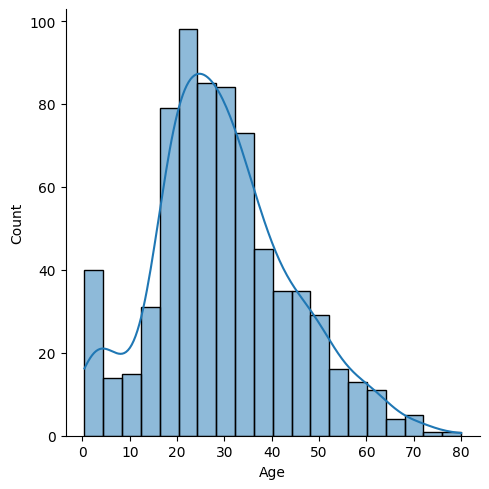

In [518]:
sns.displot(df["Age"], kde = True)

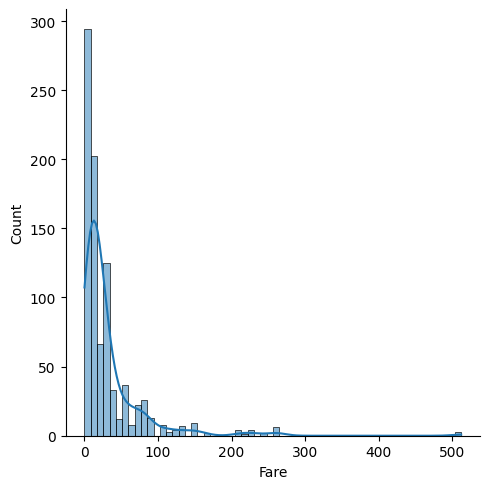

In [519]:
sns.displot(df["Fare"], kde = True)

<Axes: ylabel='Age'>

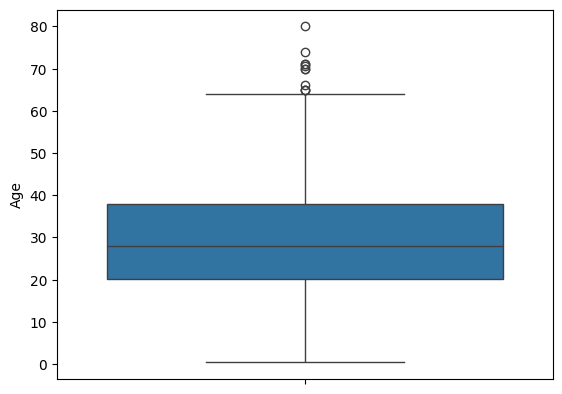

In [520]:
sns.boxplot(df["Age"])

<Axes: ylabel='Fare'>

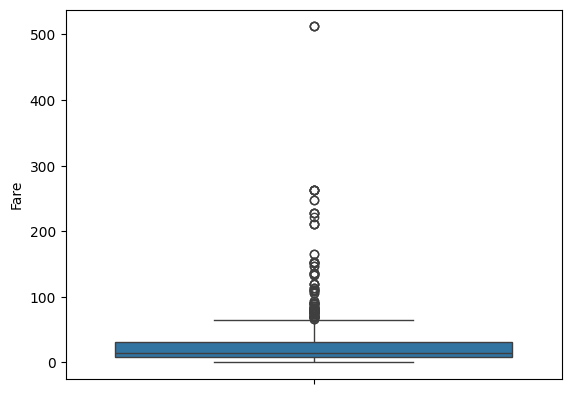

In [521]:
sns.boxplot(df["Fare"])

In [522]:
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

simp_fare = SimpleImputer(strategy="most_frequent")
simp_age = SimpleImputer(strategy="mean")

In [523]:
df["Fare"] = simp_fare.fit_transform(df[["Fare"]])
df["Age"] = simp_age.fit_transform(df[["Age"]])

In [524]:
df.isnull().sum()


Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64

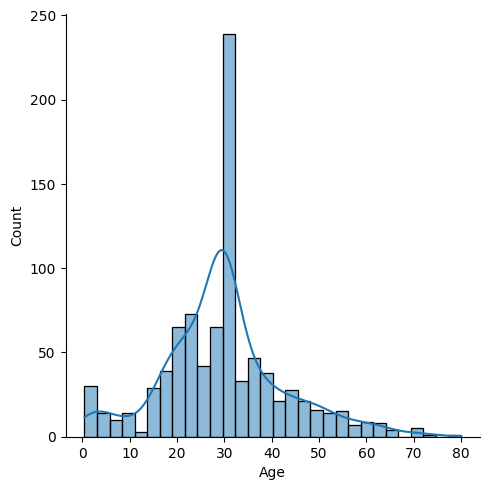

In [525]:
sns.displot(df["Age"], kde = True)

In [526]:
df = df.drop(columns = ["SibSp", "Parch"])

In [527]:
df

,Survived,Pclass,Sex,Age,Fare,Embarked
0,0,3,male,22.000000,7.2500,S
1,1,1,female,38.000000,71.2833,C
2,1,3,female,26.000000,7.9250,S
3,1,1,female,35.000000,53.1000,S
4,0,3,male,35.000000,8.0500,S
...,...,...,...,...,...,...
886,0,2,male,27.000000,13.0000,S
887,1,1,female,19.000000,30.0000,S
888,0,3,female,29.699118,23.4500,S
889,1,1,male,26.000000,30.0000,C


In [528]:
from sklearn.preprocessing import OneHotEncoder

sex_encoder = OneHotEncoder(drop="first", sparse_output=False)
pclass_encoder = OneHotEncoder(drop="first", sparse_output=False)

sex_ohe = sex_encoder.fit_transform(df[["Sex"]])
pclass_ohe = pclass_encoder.fit_transform(df[["Pclass"]])

sex_df = pd.DataFrame(
    sex_ohe,
    columns=sex_encoder.get_feature_names_out(["Sex"]),
    index=df.index
)

pclass_df = pd.DataFrame(
    pclass_ohe,
    columns=pclass_encoder.get_feature_names_out(["Pclass"]),
    index=df.index
)



In [529]:
df = pd.concat([df, sex_df], axis = 1)
df = pd.concat([df, pclass_df],axis = 1)

<Axes: ylabel='Age'>

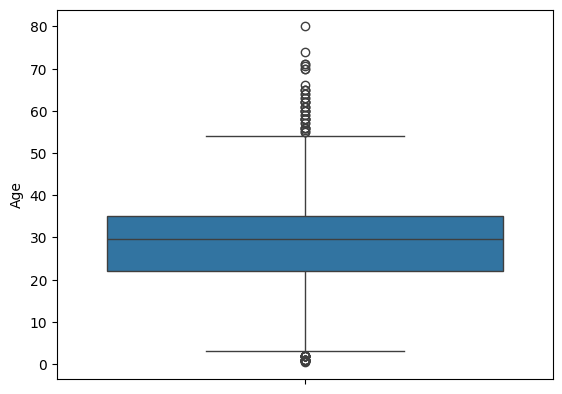

In [530]:
sns.boxplot(df["Age"])

<Axes: ylabel='Fare'>

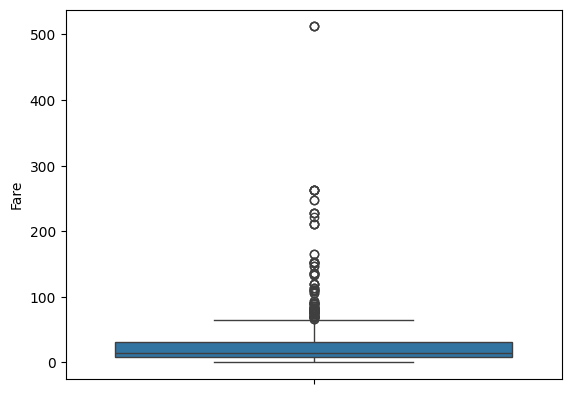

In [531]:
sns.boxplot(df["Fare"])

In [532]:
age_25 = df["Age"].quantile(.25)
age_75 = df["Age"].quantile(.75)
iqr_age = age_75 - age_25
l_age = age_25 - 1.5 * iqr_age
u_age = age_75 + 1.5 * iqr_age

fare_25 = df["Fare"].quantile(.25)
fare_75 = df["Fare"].quantile(.75)
iqr_fare = fare_75 - fare_25
l_fare = fare_25 - 1.5 * iqr_fare
u_fare = fare_75 + 1.5 * iqr_fare

In [533]:
from sklearn.preprocessing import FunctionTransformer
log = FunctionTransformer(np.log1p)
df["Fare"] = log.fit_transform(df[["Fare"]])

In [534]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["Age", "Fare"]] = scaler.fit_transform(df[["Age", "Fare"]])

In [535]:
df = df.drop(columns = ["Pclass", "Sex", "Embarked"])

In [536]:
df

,Survived,Age,Fare,Sex_male,Pclass_2,Pclass_3
0,0,-0.592481,-0.879741,1.0,0.0,1.0
1,1,0.638789,1.361220,0.0,0.0,0.0
2,1,-0.284663,-0.798540,0.0,0.0,1.0
3,1,0.407926,1.062038,0.0,0.0,0.0
4,0,0.407926,-0.784179,1.0,0.0,1.0
...,...,...,...,...,...,...
886,0,-0.207709,-0.333698,1.0,1.0,0.0
887,1,-0.823344,0.487082,0.0,0.0,0.0
888,0,0.000000,0.242007,0.0,0.0,1.0
889,1,-0.284663,0.487082,1.0,0.0,0.0


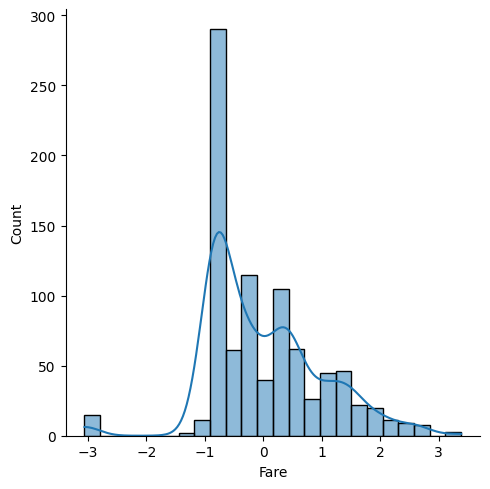

In [537]:
sns.displot(df["Fare"], kde = True)

In [538]:
from numpy.matlib import rand
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
x_train,x_test, y_train, y_test = train_test_split(df.drop(columns = ["Survived"]), df["Survived"], test_size = 0.2, random_state=42)
lr = LogisticRegression(random_state=42)
lr.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [539]:
y_pred = lr.predict(x_test)

In [540]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=1000)

scores = cross_val_score(
    lr,
    df.drop(columns=["Survived"]),
    df["Survived"],
    cv=5,
    scoring="accuracy"
)

print(scores)
print("Average Accuracy:", scores.mean())

[0.77094972 0.81460674 0.78651685 0.76404494 0.79213483]
Average Accuracy: 0.7856506182913817
